In [35]:
import pandas as pd
import keras
from keras.layers import LSTM, Input, Flatten, Dense, Lambda, Reshape, Activation, ReLU, Dropout
from keras.models import Model, Sequential
from keras import backend as K
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, confusion_matrix, precision_score, recall_score
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, f1_score
import seaborn as sns


In [184]:
# Cargar el dataset
# Ficheros V1
file_train = r"C:\Users\Usuario\Desktop\LSTM2\datos\OLD\datos_entrenamiento_serie_sat3.xlsx"
file_test = r"C:\Users\Usuario\Desktop\LSTM2\datos\OLD\datos_validacion_serie_sat3.xlsx"

# Ficheros V2
# file_train = r"C:\Users\Usuario\Desktop\LSTM2\datos\N\N_datos_entrenamiento_serie_sat3.xlsx"
# file_test = r"C:\Users\Usuario\Desktop\LSTM2\datos\N\N_datos_validacion_serie_sat3.xlsx"

X_train = pd.read_excel(file_train, sheet_name = "Sheet1", index_col = 0)
X_test = pd.read_excel(file_test, sheet_name = "Sheet1", index_col = 0)

In [185]:
# Preparar los datos de entrenamiento
X_train = X_train[X_train.anomaly == 0]  ## Usaremos únicamente la clase 0 (transacciones normales)
Y_train = X_train['anomaly'] #identificación de si los datos de train son anómalos o no
X_train = X_train.drop(columns = ["anomaly"], axis=1)
X_train_columns = X_train.columns
X_train = X_train.values

# Preparar los datos de test
Y_test = X_test['anomaly'] #identificación de si los datos de test son anómalos o no
X_test = X_test.drop(columns = ["anomaly"], axis=1)
X_test_columns = X_test.columns
X_test = X_test.values
X_test = X_test.reshape(1, X_test.shape[0], X_test.shape[1])

In [186]:
print(X_train.shape, X_test.shape, Y_train.shape)
indices = np.arange(len(X_train))
print(indices.shape)

(2006, 30) (1, 1003, 30) (2006,)
(2006,)


In [187]:
# Dividimos los datos: 60% train, 40% validación
train_size1 = int(len(X_train) * 0.6)

# Split into training and test sets
X_val = X_train[train_size1:]
X_train = X_train[:train_size1]

Y_val = Y_train[train_size1:]
Y_train = Y_train[:train_size1]

In [188]:
X_train = X_train.reshape(1, X_train.shape[0], X_train.shape[1])
X_val = X_val.reshape(1, X_val.shape[0], X_val.shape[1])

In [189]:
# Definimos la arquitectura del modelo
model = tf.keras.models.Sequential([
  tf.keras.layers.LSTM(64, return_sequences=True),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.LSTM(64, return_sequences=True),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(X_train.shape[2], activation='sigmoid'),
])

# Compilamos el modelo
model.compile(keras.optimizers.Adam(learning_rate=0.001), loss='mse')

In [190]:
# Definicion de early_stopping
early_stopping = EarlyStopping(monitor='val_loss',
                               patience=5,
                               restore_best_weights=True)

In [191]:
##### Entrenamos el modelo
model.fit(X_train,X_train,verbose=1,epochs=50, batch_size=32, validation_data=(X_val, X_val), callbacks=[early_stopping])

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.1761 - val_loss: 0.1649
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - loss: 0.1653 - val_loss: 0.1542
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - loss: 0.1549 - val_loss: 0.1438
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - loss: 0.1449 - val_loss: 0.1335
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - loss: 0.1349 - val_loss: 0.1238
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - loss: 0.1255 - val_loss: 0.1149
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - loss: 0.1170 - val_loss: 0.1070
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - loss: 0.1094 - val_loss: 0.1002
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - loss: 0.1028 - val_loss: 0.0945
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - loss: 0.0972 - val_loss: 0.0895
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - loss: 0.0926 - val_loss: 0.0852
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - loss: 0.0885 - val_loss:

### Umbral para la identificación de anomalías

In [208]:
# Definimos un umbral a través del cual si una reconstrucción tiene un error superior a este, el modelo clasifica este ítem como anomalía
pred = model.predict(X_val)
ecm=np.mean(np.power(X_val-pred, 2), axis=1)
umbral_fijo=np.percentile(ecm, 75)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


### Evaluación modelo

In [209]:
reconstructed_test = model.predict(X_test)
ecm_test=np.mean(np.power(X_test-reconstructed_test, 2), axis=2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


In [210]:
Y_pred_test = [1 if e > umbral_fijo else 0 for e in ecm_test[0]]
conf_matrix = confusion_matrix(Y_test, Y_pred_test)
print(conf_matrix)

[[602 250]
 [ 52  99]]


In [211]:
precision = precision_score(Y_test, Y_pred_test)
recall = recall_score(Y_test, Y_pred_test)
f1 = f1_score(Y_test, Y_pred_test)
print(round(precision, 3), round(recall, 3), round(f1, 3))

0.284 0.656 0.396


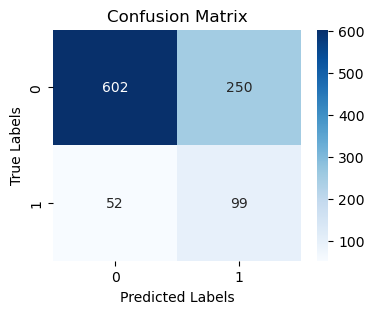

In [212]:
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()